In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import glm
from scipy.stats import poisson, nbinom


## Salamanders yay

In [78]:
salamanders =  pd.read_csv("data/salamanders.csv",sep=";")

In [79]:
#Standardize predictors
salamanders['PCTCOVER_stda'] = (salamanders.PCTCOVER - np.mean(salamanders.PCTCOVER))/np.std(salamanders.PCTCOVER);
salamanders['FORESTAGE_stda'] = (salamanders.FORESTAGE - np.mean(salamanders.FORESTAGE))/np.std(salamanders.FORESTAGE);

In [82]:
print(np.mean(SALAMANDERS),np.std(SALAMANDERS),np.var(SALAMANDERS))

2.4680851063829787 3.3380530943713307 11.142598460842017


In [83]:
family_GLM = sm.families.Poisson()

formula = 'SALAMAN ~ PCTCOVER_stda'
poisson_pct = glm(formula = formula, data = salamanders, family = family_GLM).fit()
print(poisson_pct.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                SALAMAN   No. Observations:                   47
Model:                            GLM   Df Residuals:                       45
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -103.18
Date:                Tue, 18 Feb 2025   Deviance:                       121.31
Time:                        15:36:22   Pearson chi2:                     123.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.7692
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4295      0.158      2.712

In [85]:
poisson_lambda = np.exp(poisson_pct.params.iloc[0] + poisson_pct.params.iloc[1] * salamanders.PCTCOVER_stda)

poisson_list_lower = []
poisson_list_upper = []
for l in poisson_lambda:
    temp_dist = poisson.rvs(l, size=1000)
    qs = np.quantile(temp_dist,[0.1,0.5,0.9])
    poisson_list_lower.append(qs[0])
    poisson_list_upper.append(qs[2])

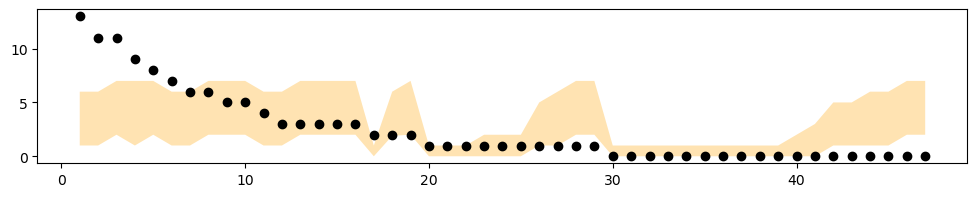

In [61]:
plt.figure(figsize=(12, 2))
plt.plot(salamanders.SITE,salamanders.SALAMAN,'o',color='black')
plt.fill_between(salamanders.SITE, poisson_list_lower, poisson_list_upper, facecolor='orange', alpha=0.3)
plt.show()


In [94]:
family_GLM = sm.families.NegativeBinomial(alpha=0.62)
nbinom_pct = glm(formula = formula, data = salamanders, family = family_GLM).fit()
print(nbinom_pct.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                SALAMAN   No. Observations:                   47
Model:                            GLM   Df Residuals:                       45
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -85.683
Date:                Tue, 18 Feb 2025   Deviance:                       53.182
Time:                        15:37:53   Pearson chi2:                     48.3
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4945
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4399      0.195      2.253

In [18]:
formula = 'SALAMAN ~ PCTCOVER_stda + FORESTAGE_stda'
model_GLM_pct_fores = glm(formula = formula, data = salamanders, family = family_GLM).fit()
print(model_GLM_pct_fores.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                SALAMAN   No. Observations:                   47
Model:                            GLM   Df Residuals:                       44
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -103.18
Date:                Tue, 18 Feb 2025   Deviance:                       121.30
Time:                        10:00:53   Pearson chi2:                     123.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.7692
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4293      0.158      2.

## Hurricanes

In [5]:
hurricanes =  pd.read_csv("data/Hurricanes.csv",sep=";")
hurricanes[1:3]

,name,year,deaths,category,min_pressure,damage_norm,female,femininity
1,King,1950,4,3,955,5350,0,1.38889
2,Able,1952,3,1,985,150,0,3.83333


In [6]:
hurricanes['min_pressure_stda'] = (hurricanes.min_pressure - np.mean(hurricanes.min_pressure))/np.std(hurricanes.min_pressure)
hurricanes['femininity_stda'] = (hurricanes.femininity - np.mean(hurricanes.femininity))/np.std(hurricanes.femininity)
hurricanes['damage_norm_stda'] = (hurricanes.damage_norm - np.mean(hurricanes.damage_norm))/np.std(hurricanes.damage_norm)

In [12]:
family_GLM = sm.families.NegativeBinomial(alpha=10)

formula = 'deaths ~ femininity_stda * (min_pressure_stda + damage_norm_stda)'
m = glm(formula = formula, data = hurricanes, family = family_GLM).fit()
print(m.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 deaths   No. Observations:                   92
Model:                            GLM   Df Residuals:                       86
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -392.23
Date:                Thu, 20 Feb 2025   Deviance:                       17.574
Time:                        10:00:46   Pearson chi2:                     13.4
No. Iterations:                    27   Pseudo R-squ. (CS):             0.1077
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

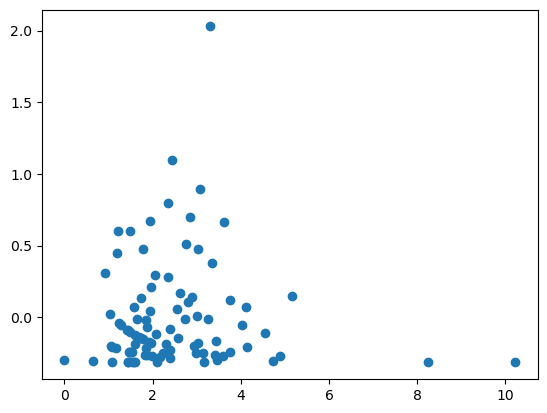

In [27]:
residuals = m.resid_pearson
fitted = m.fittedvalues
plt.scatter(np.log(fitted),residuals)

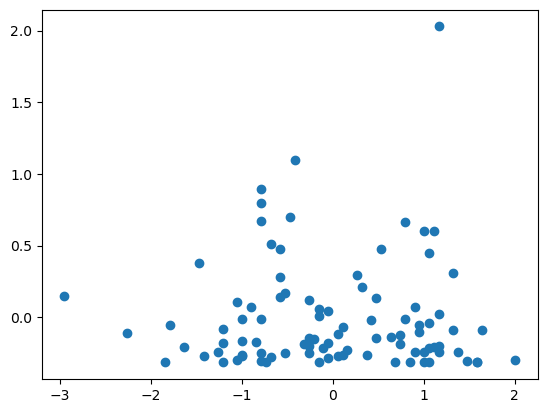

In [29]:
plt.scatter(hurricanes.min_pressure_stda,residuals)

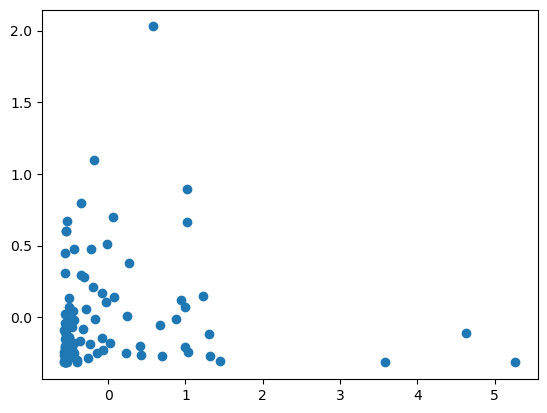

In [30]:
plt.scatter(hurricanes.damage_norm_stda,residuals)

In [114]:
# Calculate n and p for the Negative Binomial distribution
# Get the predicted mean (mu) for each observation
predicted_mu = m.predict()
# Get the dispersion parameter (alpha)
alpha = m.family.alpha
n = 1 / alpha  # n is the number of successes
p = n / (n + predicted_mu)  # p is the probability of success

# Simulate data for each observation
simulated_data = np.array([nbinom.rvs(n=n, p=p_i) for p_i in p])

In [81]:
n_simulations = 1000
simulated_datasets = np.array([[nbinom.rvs(n=n, p=p_i) for p_i in p] for _ in range(n_simulations)])

# Print the shape of the simulated datasets (1000 simulations x 100 observations)
print("Shape of Simulated Datasets:")
print(simulated_datasets.shape)

Shape of Simulated Datasets:
(1000, 92)


In [99]:
quantiles = np.quantile(simulated_datasets, q=[0.025, 0.5, 0.975], axis=0)
np.shape(quantiles)
#plt.scatter(hurricanes.deaths,p50)

(3, 92)

In [104]:
quantiles[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [92]:
#df = pd.DataFrame(simulated_datasets)
##np.shape(df)
#quantiles = simulated_datasets.quantile([0.25, 0.5, 0.75], axis=1)

In [69]:
b0, b1, b2, b3, b4, b5 = m.params
femininity = 3
U = b0 + b1*femininity + b2*hurricanes.min_pressure_stda + b3*hurricanes.damage_norm_stda + b4*femininity*hurricanes.min_pressure_stda + b5 * femininity * hurricanes.damage_norm_stda

In [70]:
result_list = []
for u in U:
    result_list.append(nbinom.rvs(u,0.2,size=1000))

In [71]:
np.shape(result_list)

(92, 1000)

In [49]:
df = pd.DataFrame(result_list)
np.shape(df)
quantiles = df.quantile([0.25, 0.5, 0.75], axis=1)

In [55]:
quantiles

,0,1,2,3,4,5,6,7,8,9,...,82,83,84,85,86,87,88,89,90,91
0.25,2.0,4.0,3.0,3.0,3.0,14.0,2.0,16.0,2.0,13.0,...,2.0,5.0,19.0,3.0,2.0,3.0,14.0,4.0,19.0,59.0
0.50,4.0,7.0,6.0,6.0,6.0,20.0,5.0,22.0,5.0,19.0,...,6.0,10.0,25.0,6.0,5.0,6.0,20.0,8.0,25.0,71.0
0.75,8.0,12.0,10.0,10.0,11.0,28.0,9.0,30.0,8.0,28.0,...,10.0,16.0,33.0,10.0,8.0,10.0,27.0,13.0,33.0,83.0


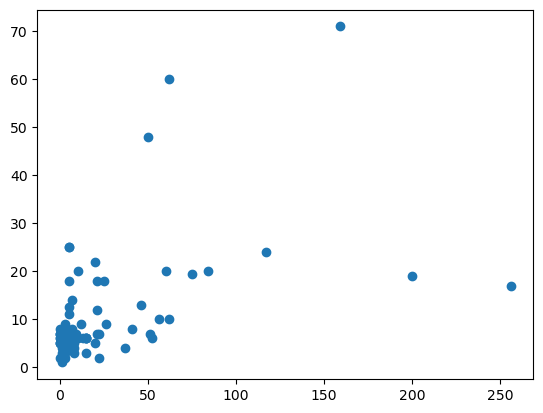

In [61]:
p50=quantiles.iloc[1]
plt.scatter(hurricanes.deaths,p50)

In [53]:
plt.plot(quantiles[2,:])

KeyError: (2, slice(None, None, None))

## hurricanes - homework model

In [73]:
family_GLM = sm.families.NegativeBinomial(alpha=10)

formula = 'deaths ~ femininity_stda + min_pressure_stda'
m = glm(formula = formula, data = hurricanes, family = family_GLM).fit()
print(m.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 deaths   No. Observations:                   92
Model:                            GLM   Df Residuals:                       89
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -395.27
Date:                Thu, 20 Feb 2025   Deviance:                       23.651
Time:                        11:43:33   Pearson chi2:                     46.5
No. Iterations:                    14   Pseudo R-squ. (CS):            0.04672
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.7874      0.33

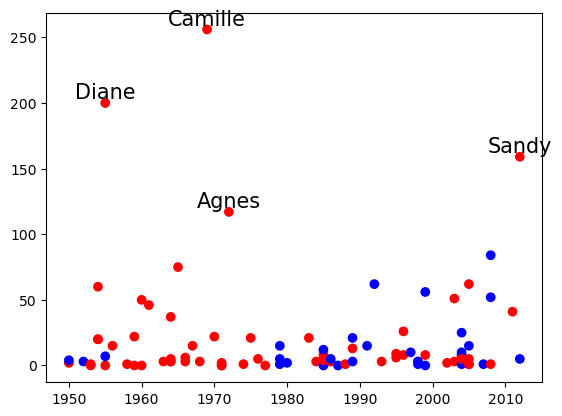

In [206]:

BigH = np.where(hurricanes.deaths >100)[0]
colors = {0:'blue', 1:'red'}

plt.scatter(hurricanes.year,hurricanes.deaths,c=hurricanes['female'].map(colors))
for i in BigH:
    plt.text(hurricanes.year[i],hurricanes.deaths[i],hurricanes.name[i],ha='center', va='bottom',size=15)


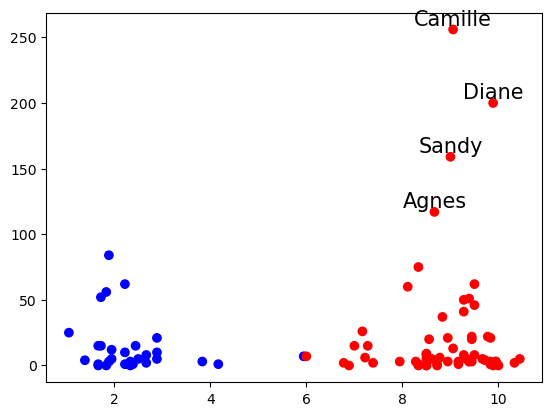

In [208]:
plt.scatter(hurricanes.femininity,hurricanes.deaths,c=hurricanes['female'].map(colors))
for i in BigH:
    plt.text(hurricanes.femininity[i],hurricanes.deaths[i],hurricanes.name[i],ha='center', va='bottom',size=15)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 deaths   No. Observations:                   92
Model:                            GLM   Df Residuals:                       89
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1608.2
Date:                Tue, 18 Feb 2025   Deviance:                       2891.5
Time:                        17:58:58   Pearson chi2:                 7.25e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.7369      0.02

In [216]:
residuals = poisson_pct.resid_pearson

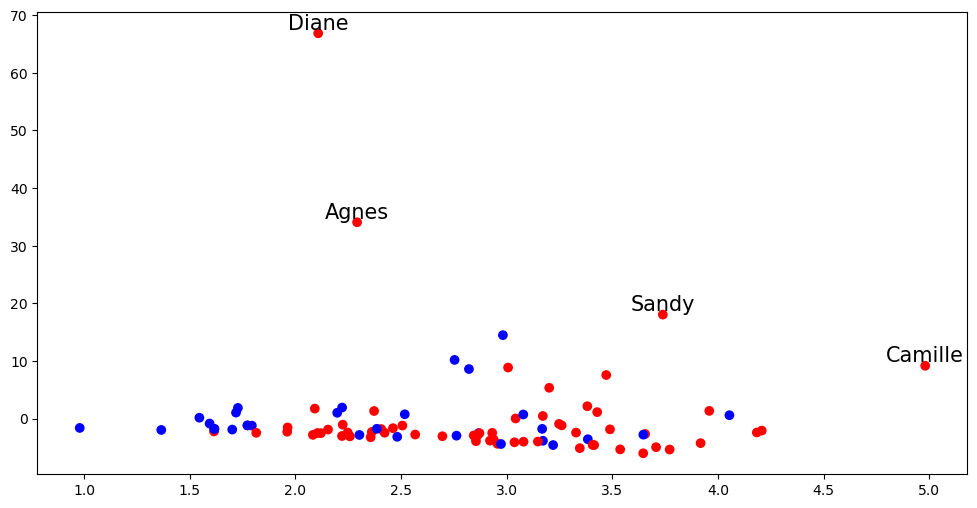

In [217]:
plt.figure(figsize=(12, 6))
plt.scatter(np.log(poisson_pct.fittedvalues),residuals,c=hurricanes['female'].map(colors))
for i in BigH:
    plt.text(np.log(poisson_pct.fittedvalues[i]),residuals[i],hurricanes.name[i],ha='center', va='bottom',size=15)
plt.show()

In [132]:
family_GLM = sm.families.NegativeBinomial(alpha=0.1)

formula = 'deaths ~ min_pressure_stda + femininity_stda'
nbinom = glm(formula = formula, data = hurricanes, family = family_GLM).fit()
print(nbinom.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 deaths   No. Observations:                   92
Model:                            GLM   Df Residuals:                       89
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -668.36
Date:                Tue, 18 Feb 2025   Deviance:                       944.79
Time:                        17:59:30   Pearson chi2:                 2.63e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.9555
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.7935      0.04

## Autocorrelation

In [218]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg

In [225]:
surge =  pd.read_csv("data/norfolk-hourly-surge-2015.csv",sep=",")
surge["weather_surge"] = surge["Verified (m)"] - surge["Predicted (m)"]

In [224]:
surge[1:2]

,Date,Time (GMT),Predicted (m),Preliminary (m),Verified (m)
1,2015/01/01,01:00,0.325,-,0.432


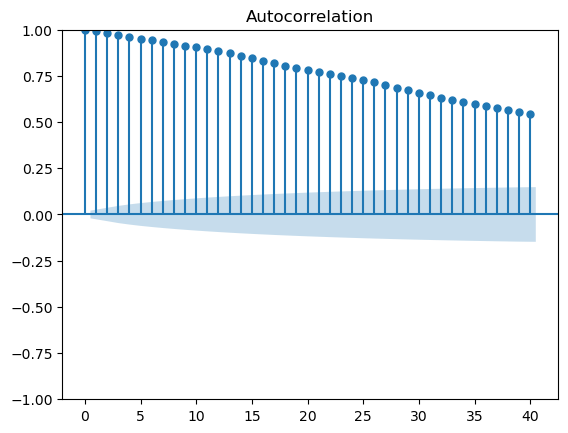

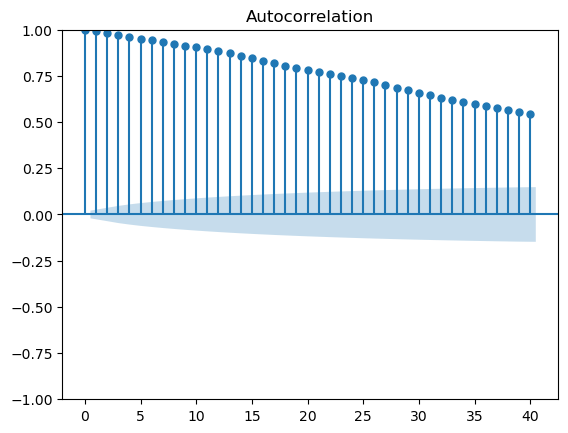

In [227]:
plot_acf(surge["weather_surge"])

In [ ]:
surge['weather_surge'].corr(surge['weather_surge'].shift(1))

0.9940753411059986

In [240]:
# Create and train the autoregressive model
lag_order = 1 # Adjust this based on the ACF plot
ar_model = AutoReg(surge['weather_surge'], lags=lag_order)
ar_results = ar_model.fit()
print(ar_results.summary())


                            AutoReg Model Results                             
Dep. Variable:          weather_surge   No. Observations:                 8760
Model:                     AutoReg(1)   Log Likelihood               21988.604
Method:               Conditional MLE   S.D. of innovations              0.020
Date:                Tue, 18 Feb 2025   AIC                         -43971.207
Time:                        22:43:04   BIC                         -43949.974
Sample:                             1   HQIC                        -43963.972
                                 8760                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0006      0.000      2.601      0.009       0.000       0.001
weather_surge.L1     0.9942      0.001    855.942      0.000       0.992       0.996
                            

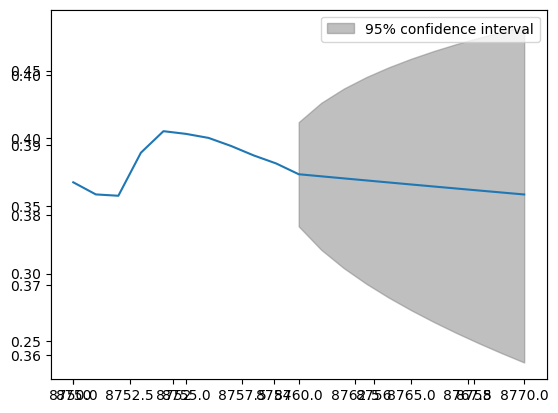

In [262]:
fig, ax = plt.subplots()
ax = surge['weather_surge'][8750:8760].plot(ax=ax)
fig = ar_results.plot_predict(8750, 8770,fig=fig)
plt.show()


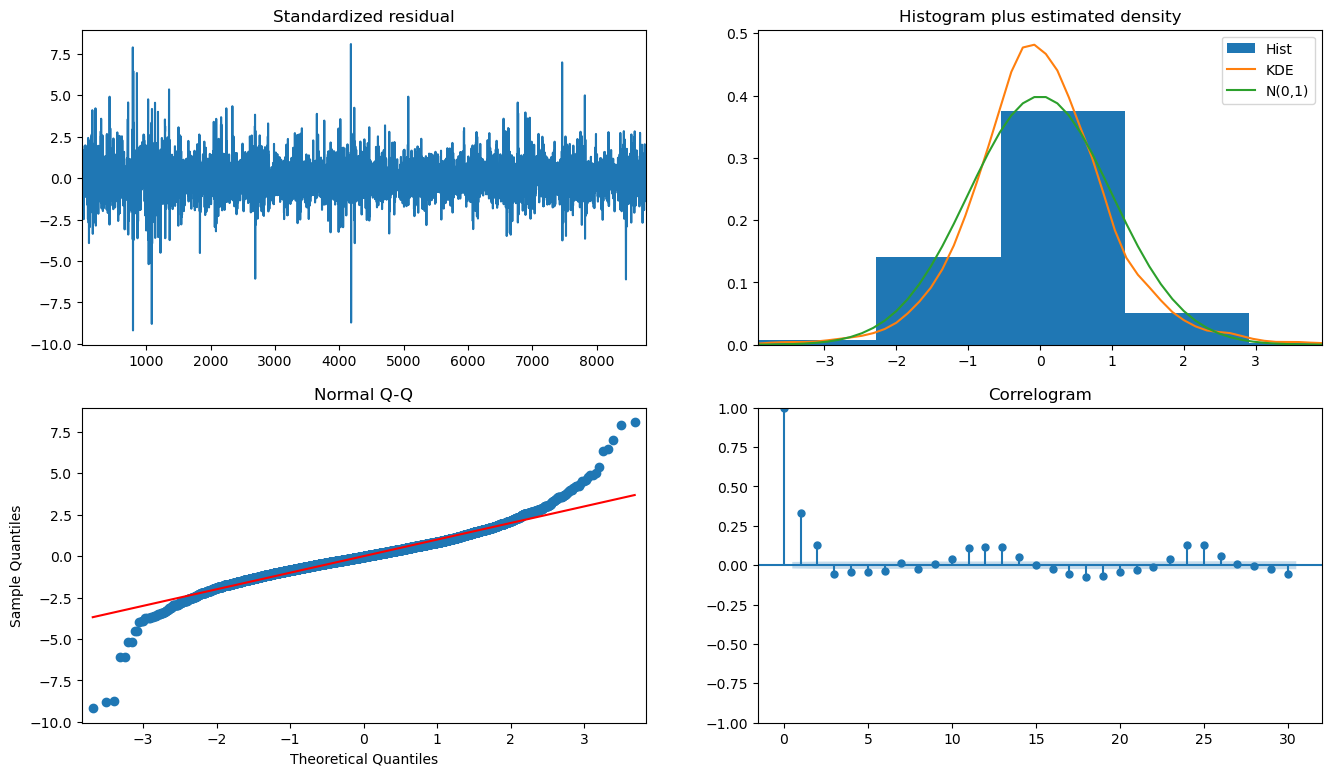

In [241]:
fig = plt.figure(figsize=(16, 9))
fig = ar_results.plot_diagnostics(fig=fig, lags=30)